# Production EDA

Notebook này chỉ dùng file `prod_long_cleaned.csv` với 4 cột `name`, `unit`, `period`, `value`.

Mục tiêu là xem thống kê tổng quan, tìm điểm bất thường, và kiểm tra tương quan giữa 2 dòng sản phẩm theo tháng.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df = pd.read_csv('../prod_long_cleaned.csv')
df['name'] = df['name'].astype(str).str.strip()
df['unit'] = df['unit'].astype(str).str.strip()
df['period'] = df['period'].astype(str).str.strip()
df['value'] = pd.to_numeric(df['value'], errors='coerce')

df_monthly = df[df['period'].isin(month_order)].copy()

yb_fill0_mask = df_monthly['name'].eq('Production (YB Powder)') & df_monthly['value'].eq(0)
df_monthly.loc[yb_fill0_mask, 'value'] = np.nan

df_monthly['period'] = pd.Categorical(df_monthly['period'], categories=month_order, ordered=True)
df_monthly = df_monthly.sort_values(['name', 'period']).reset_index(drop=True)

display(df_monthly.head(10))
print('Rows:', len(df_monthly))
print('Products:', df_monthly['name'].nunique())
print('Units:', df_monthly['unit'].nunique())
print('Missing values:', df_monthly['value'].isna().sum())
print('YB Powder fill-0 converted to NaN:', int(yb_fill0_mask.sum()))
print('Duplicates:', df_monthly.duplicated().sum())

,name,unit,period,value
0,Production (DV Tile),ton,Jan,9609.931000
1,Production (DV Tile),ton,Feb,6310.080933
2,Production (DV Tile),ton,Mar,17732.973467
3,Production (DV Tile),ton,Apr,15795.455367
4,Production (DV Tile),ton,May,16091.799767
5,Production (DV Tile),ton,Jun,16408.015833
6,Production (DV Tile),ton,Jul,18454.323805
7,Production (DV Tile),ton,Aug,16179.630248
8,Production (DV Tile),ton,Sep,12136.760367
9,Production (DV Tile),ton,Oct,12464.841216


Rows: 24
Products: 2
Units: 1
Missing values: 11
YB Powder fill-0 converted to NaN: 11
Duplicates: 0


In [ ]:
min_points_for_deep_analysis = 3

non_missing_count = df_monthly.groupby('name')['value'].apply(lambda s: s.notna().sum())
eligible_products = non_missing_count[non_missing_count >= min_points_for_deep_analysis].index.tolist()
excluded_products = non_missing_count[non_missing_count < min_points_for_deep_analysis].index.tolist()

df_deep = df_monthly[df_monthly['name'].isin(eligible_products)].copy()

print('Non-missing points by product:')
print(non_missing_count.to_string())
print(f'Eligible products (>= {min_points_for_deep_analysis} points): {eligible_products}')
print(f'Excluded from deep analysis: {excluded_products}')

Non-missing points by product:
name
Production (DV Tile)      12
Production (YB Powder)     1
Eligible products (>= 3 points): ['Production (DV Tile)']
Excluded from deep analysis: ['Production (YB Powder)']


## Quy tắc xử lý missing cho YB Powder

`YB Powder` có nhiều giá trị thiếu do trước đó bị `fill 0` trong bước clean. Vì đây không phải số đo thực, notebook này **không nội suy/fill median** cho chuỗi này.

Cách dùng:
- Giữ `NaN` cho phân tích mô tả và biểu đồ để phản ánh đúng chất lượng dữ liệu.
- Chỉ đưa sản phẩm vào phân tích sâu (outlier/correlation) khi có đủ số điểm quan sát thực.

## 1. Thống kê tổng quan

Bảng này cho biết mức tiêu thụ/sản lượng trung bình, trung vị, độ lệch chuẩn và biên độ theo từng sản phẩm. Với dữ liệu chỉ có 2 sản phẩm, phần nhìn quan trọng nhất là mức chênh giữa `DV Tile` và `YB Powder`.

In [13]:
summary = df_monthly.groupby('name')['value'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)
monthly_total = df_monthly.groupby('period')['value'].sum(min_count=1).reindex(month_order).round(3)
missing_rate = (df_monthly['value'].isna().mean() * 100).round(1)

display(summary)
print('Monthly total:')
display(monthly_total.to_frame('total_value'))
print(f'Missing rate (sau khi đổi fill-0 của YB Powder thành NaN): {missing_rate}%')

,count,mean,median,std,min,max
name,,,,,,
Production (DV Tile),12,14090.686,15687.862,3584.914,6310.081,18454.324
Production (YB Powder),1,423.667,423.667,NaN,423.667,423.667


Monthly total:


,total_value
period,
Jan,9609.931
Feb,6310.081
Mar,17732.973
Apr,15795.455
May,16091.800
Jun,16408.016
Jul,18454.324
Aug,16179.630
Sep,12136.760


Missing rate (sau khi đổi fill-0 của YB Powder thành NaN): 45.8%


## 2. Outliers và xu hướng

Dùng IQR để bắt các tháng lệch so với phần còn lại. Vì các giá trị `0` của `YB Powder` là giá trị fill từ bước clean (đã đổi thành `NaN`), phần outlier chủ yếu tập trung ở chuỗi `DV Tile`; riêng `YB Powder` cần đối chiếu thêm dữ liệu gốc trước khi kết luận bất thường.

Điều này không tự động đồng nghĩa lỗi dữ liệu, nhưng là chỗ cần đối chiếu với nhật ký vận hành, kế hoạch sản xuất, hoặc sự kiện bất thường trong tháng.

,name,period,value,lower_bound,upper_bound
0,Production (DV Tile),Feb,6310.081,6338.158,22175.868


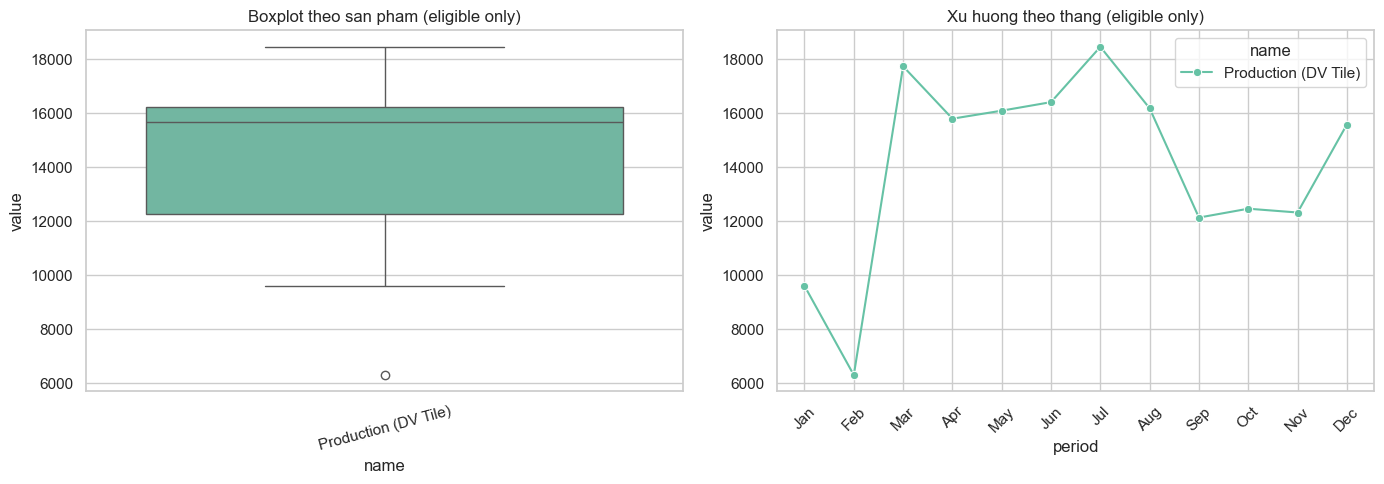

In [14]:
def iqr_outliers(group):
    q1 = group['value'].quantile(0.25)
    q3 = group['value'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = group[(group['value'] < lower) | (group['value'] > upper)].copy()
    flagged['lower_bound'] = lower
    flagged['upper_bound'] = upper
    return flagged

outlier_cols = ['name', 'period', 'value', 'lower_bound', 'upper_bound']
outlier_frames = []

for product_name, g in df_deep.groupby('name'):
    flagged = iqr_outliers(g)
    if not flagged.empty:
        outlier_frames.append(flagged.assign(name=product_name))

if outlier_frames:
    outliers = pd.concat(outlier_frames, ignore_index=True)
    display(outliers[outlier_cols].round(3))
else:
    outliers = pd.DataFrame(columns=outlier_cols)
    print('No outliers detected in eligible products.')
    display(outliers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_deep, x='name', y='value', ax=axes[0])
axes[0].set_title('Boxplot theo san pham (eligible only)')
axes[0].tick_params(axis='x', rotation=15)

sns.lineplot(data=df_deep, x='period', y='value', hue='name', marker='o', ax=axes[1])
axes[1].set_title('Xu huong theo thang (eligible only)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Tương quan

Vì file chỉ có 2 dòng sản phẩm, tương quan hợp lý nhất là giữa 2 chuỗi theo tháng sau khi pivot sang wide format. Tuy nhiên sau khi đổi `fill 0` của `YB Powder` thành `NaN`, chỉ còn rất ít tháng có đủ cặp dữ liệu, nên nếu không đủ điểm giao nhau thì không diễn giải tương quan.

In [16]:
wide = df_deep.pivot(index='period', columns='name', values='value').reindex(month_order)
paired = wide.dropna()

print(f"Products used for deep analysis: {sorted(df_deep['name'].unique().tolist())}")
print(f'Overlapping months with complete values: {len(paired)}')
display(wide.round(3))

if wide.shape[1] >= 2 and len(paired) >= 2:
    corr = paired.corr(method='pearson')
    spearman = paired.corr(method='spearman')
    display(corr.round(3))
    display(spearman.round(3))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(corr, annot=True, cmap='Greens', vmin=-1, vmax=1, center=0, ax=ax)
    ax.set_title('Pearson correlation')
    plt.tight_layout()
    plt.show()
else:
    print('Khong du dieu kien de tinh correlation sau khi loc san pham du du lieu.')

Products used for deep analysis: ['Production (DV Tile)']
Overlapping months with complete values: 12


name,Production (DV Tile)
period,
Jan,9609.931
Feb,6310.081
Mar,17732.973
Apr,15795.455
May,16091.800
Jun,16408.016
Jul,18454.324
Aug,16179.630
Sep,12136.760


Khong du dieu kien de tinh correlation sau khi loc san pham du du lieu.


## Kết luận

- `DV Tile` là nguồn biến động chính, trung bình khoảng 14.1k mỗi tháng, cao hơn rất nhiều so với `YB Powder`.
- Các giá trị `0` của `YB Powder` trong file clean là do thao tác `fill 0`, không phải số đo thực, nên đã được đổi sang `NaN` trước khi phân tích.
- `DV Tile` có một tháng thấp bất thường là tháng 2, cần kiểm tra lại bối cảnh vận hành hoặc kế hoạch sản xuất của tháng đó.
- Tương quan giữa hai chuỗi tháng chỉ mang tính tham khảo vì chuỗi `YB Powder` thiếu dữ liệu thực ở phần lớn tháng.
- Nếu muốn đi xa hơn, bước tiếp theo nên là đối chiếu file này với năng lượng hoặc nguyên liệu, vì riêng 4 cột hiện tại thì chưa thể truy nguyên nguyên nhân sự cố.